<class 'pandas.core.frame.DataFrame'>
Index: 2674 entries, 2 to 3158
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   region            2674 non-null   object 
 1   year              2674 non-null   int64  
 2   infant_mortality  2674 non-null   float64
 3   region_standard   2674 non-null   object 
dtypes: float64(1), int64(1), object(2)
memory usage: 104.5+ KB
None

Missing values by column:
 region              0
year                0
infant_mortality    0
region_standard     0
dtype: int64

Number of unique regions: 85
Number of unique years: 32

Infant mortality statistics:
 count    2674.000000
mean       71.996634
std        81.701644
min         0.000000
25%        23.000000
50%        48.000000
75%        89.000000
max       684.000000
Name: infant_mortality, dtype: float64

Top-5 observations:
           region_standard  year  infant_mortality
152   Республика Дагестан  1991             684.0
46

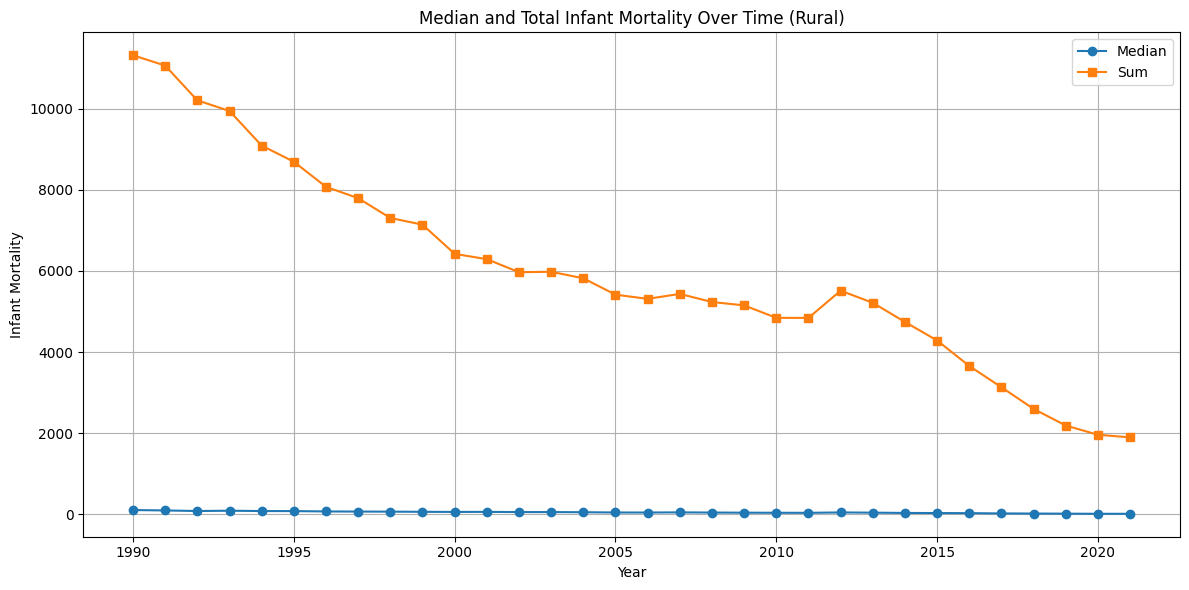

<Figure size 1600x600 with 0 Axes>

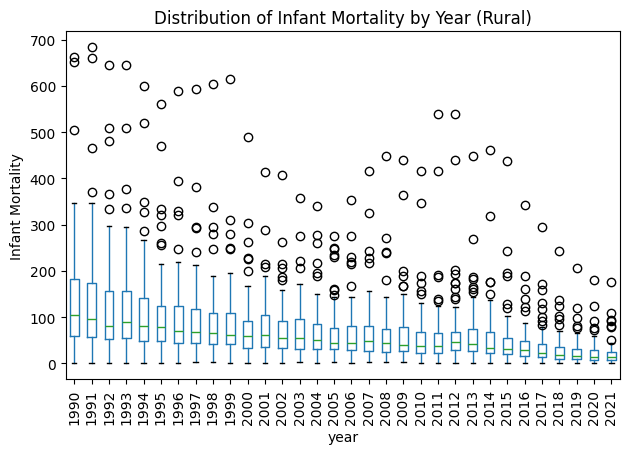

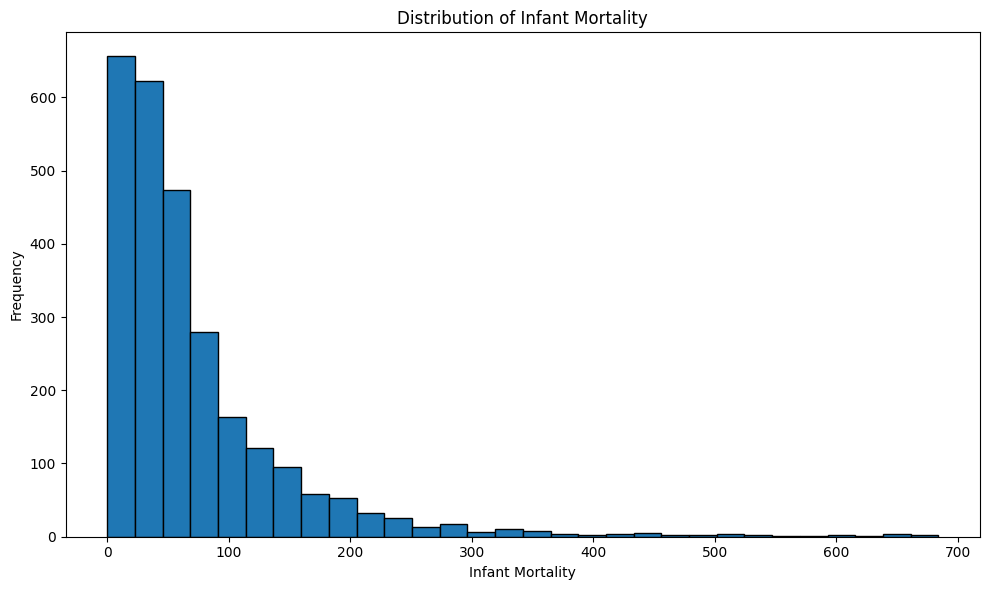

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load data
file_path = "../../outputs/standardized_datasets/child_mortality_rural_standardized.csv"
df = pd.read_csv(file_path)

# 2. Keep only rows with standardized region names
df = df[df["region_standard"].notna()].copy()

# 3. Check data types and missing values
print(df.info())
print("\nMissing values by column:\n", df.isnull().sum())

# 4. Number of unique regions and years
print("\nNumber of unique regions:", df["region_standard"].nunique())
print("Number of unique years:", df["year"].nunique())

# 5. Summary statistics
print("\nInfant mortality statistics:\n", df["infant_mortality"].describe())

# 6. Top-5 highest values
top5 = df.sort_values(by="infant_mortality", ascending=False).head(5)
print("\nTop-5 observations:\n", top5[["region_standard", "year", "infant_mortality"]])

# 7. Median and total trends
median_mortality = df.groupby("year")["infant_mortality"].median()
sum_mortality = df.groupby("year")["infant_mortality"].sum()

plt.figure(figsize=(12,6))
plt.plot(median_mortality.index, median_mortality.values, marker="o", label="Median")
plt.plot(sum_mortality.index, sum_mortality.values, marker="s", label="Sum")

plt.title("Median and Total Infant Mortality Over Time (Rural)")
plt.xlabel("Year")
plt.ylabel("Infant Mortality")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 8. Boxplot by year
plt.figure(figsize=(16,6))
df.boxplot(column="infant_mortality", by="year", grid=False, rot=90)
plt.title("Distribution of Infant Mortality by Year (Rural)")
plt.suptitle("")
plt.ylabel("Infant Mortality")
plt.tight_layout()
plt.show()

# 9. Histogram
plt.figure(figsize=(10,6))
plt.hist(df["infant_mortality"], bins=30, edgecolor="black")
plt.title("Distribution of Infant Mortality")
plt.xlabel("Infant Mortality")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# EDA of `child_mortality_rural_standardized.csv`

## Data Description
- The dataset contains 2,674 observations across 85 regions.
- Time coverage: 1990–2021.
- Key variable: infant mortality (rate per population).

---

## Data Types
- All variables are correctly formatted (float64, int64, object).
- No additional type conversion was required.

---

## Missing Values
- Aggregated rows (e.g., national totals) were removed.
- No missing values remain in the final dataset.

---

## Summary Statistics
- Mean: ~72  
- Median: 48  
- 75% of observations are below ~89  
- Maximum: 684 (Republic of Dagestan, 1991)  

The distribution is right-skewed, with higher values concentrated in earlier years.

---

## Trends Over Time
- A clear downward trend in infant mortality is observed since the 1990s.  
- The most significant improvements occur during the 2000s and later periods.  

This reflects long-term improvements in healthcare, living conditions, and maternal support systems.

---

## Distribution Patterns
- Boxplots show a more compact distribution after removing aggregated observations.  
- Earlier years exhibit higher variability, while more recent years show stabilization.  

---

## Interpretation
- Infant mortality is a key indicator of regional well-being and healthcare effectiveness.  
- Higher values in earlier periods reflect systemic challenges, while the decline indicates structural improvements.  
- Differences across regions highlight persistent inequality in health outcomes.  

This variable captures a direct outcome of socio-economic and healthcare conditions.

---

## Conclusion
The dataset is clean and suitable for further analysis.

Infant mortality provides a strong health outcome indicator and is expected to play an important role in clustering by distinguishing regions with different levels of social and healthcare development.

In [8]:
df.to_csv("../../data/clean/child_rural_AfterEDA.csv", index=False)